# 🔍 Mini-Project 3: Credit Card Fraud Detection
**AI Engineer Foundation — Python for Data Science & Mathematics for AI**

Dataset: [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

- 284,807 transactions | 492 fraud (0.172%)
- Features: V1–V28 (PCA), Time, Amount, Class

In [3]:
# !pip install numpy pandas matplotlib seaborn scikit-learn shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Load dataset — đặt file creditcard.csv vào cùng thư mục hoặc chỉnh path
df = pd.read_csv(r'D:\WORKSPACE\QuanSkill\data\raw\creditcard.csv')
print(f'Dataset shape: {df.shape}') #df đọc số cột số dòng của dataset
print(f'Fraud count: {df["Class"].sum()} / {len(df)}  ({df["Class"].mean()*100:.3f}%)') 
#df class đếm số fraud, lendf đếm tổng số giao dịch  df.class chỉ có 0 và 1 nhưng có mean thì tỉ lệ chính là 1

Dataset shape: (284807, 31)
Fraud count: 492 / 284807  (0.173%)


---
## MODULE 1: NUMPY (Q1–Q10)

In [4]:
# Q1. Load dataset vào NumPy array (V1–V28 + Amount)
#     Kiểm tra shape và dtype

feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount']
X_np = df[feature_cols].values          # numpy array shape (284807, 29)
y_np = df['Class'].values               # labels

print('=== Q1 ===')
print(f'Shape : {X_np.shape}')          # (284807, 29)
print(f'Dtype : {X_np.dtype}')          # float64
print(f'Sample row:\n{X_np[0]}')

=== Q1 ===
Shape : (284807, 29)
Dtype : float64
Sample row:
[-1.35980713e+00 -7.27811733e-02  2.53634674e+00  1.37815522e+00
 -3.38320770e-01  4.62387778e-01  2.39598554e-01  9.86979013e-02
  3.63786970e-01  9.07941720e-02 -5.51599533e-01 -6.17800856e-01
 -9.91389847e-01 -3.11169354e-01  1.46817697e+00 -4.70400525e-01
  2.07971242e-01  2.57905802e-02  4.03992960e-01  2.51412098e-01
 -1.83067779e-02  2.77837576e-01 -1.10473910e-01  6.69280749e-02
  1.28539358e-01 -1.89114844e-01  1.33558377e-01 -2.10530535e-02
  1.49620000e+02]


In [5]:
# Q2. Mean, Median, Std cho Amount và V1–V5

cols_q2 = ['Amount', 'V1', 'V2', 'V3', 'V4', 'V5']
idx_q2  = [feature_cols.index(c) for c in cols_q2]   # vị trí cột trong X_np
X_q2    = X_np[:, idx_q2]

print('=== Q2 ===')
print(f'{"Feature":<10} {"Mean":>12} {"Median":>12} {"Std":>12}')
print('-' * 50)
for i, col in enumerate(cols_q2):
    m  = np.mean(X_q2[:, i])
    md = np.median(X_q2[:, i])
    s  = np.std(X_q2[:, i])
    print(f'{col:<10} {m:>12.4f} {md:>12.4f} {s:>12.4f}')

=== Q2 ===
Feature            Mean       Median          Std
--------------------------------------------------
Amount          88.3496      22.0000     250.1197
V1               0.0000       0.0181       1.9587
V2               0.0000       0.0655       1.6513
V3              -0.0000       0.1798       1.5163
V4               0.0000      -0.0198       1.4159
V5               0.0000      -0.0543       1.3802


In [6]:
# Q3. Min-Max Normalization
#     Scale tất cả V1–V28, Amount về [0, 1]

X_min = X_np.min(axis=0)                        # shape (29,)
X_max = X_np.max(axis=0)                        # shape (29,)
X_minmax = (X_np - X_min) / (X_max - X_min)    # vectorized broadcast

print('=== Q3 ===')
print(f'Min sau normalize: {X_minmax.min():.4f}  (expected 0.0)')
print(f'Max sau normalize: {X_minmax.max():.4f}  (expected 1.0)')
print(f'Shape unchanged  : {X_minmax.shape}')

=== Q3 ===
Min sau normalize: 0.0000  (expected 0.0)
Max sau normalize: 1.0000  (expected 1.0)
Shape unchanged  : (284807, 29)


In [7]:
# Q4. Boolean indexing: Amount > 1000 VÀ Time > 86400 (ngày 2)

time_idx   = df.columns.get_loc('Time')
amount_idx = feature_cols.index('Amount')

time_col   = df['Time'].values
amount_col = X_np[:, amount_idx]

mask = (amount_col > 1000) & (time_col > 86400)
X_filtered = X_np[mask]

print('=== Q4 ===')
print(f'Transactions với Amount > 1000 & Time > 86400: {mask.sum()}')
print(f'Shape kết quả: {X_filtered.shape}')
print(f'Fraud trong nhóm này: {y_np[mask].sum()}')

=== Q4 ===
Transactions với Amount > 1000 & Time > 86400: 1395
Shape kết quả: (1395, 29)
Fraud trong nhóm này: 4


=== Q5 — Correlation Matrix (V1–V10, Amount) ===
               V1        V2        V3        V4        V5        V6        V7        V8        V9       V10    Amount
      V1    1.000    -0.000    -0.000    -0.000     0.000     0.000     0.000    -0.000     0.000     0.000    -0.228
      V2   -0.000     1.000     0.000    -0.000     0.000     0.000    -0.000    -0.000    -0.000    -0.000    -0.531
      V3   -0.000     0.000     1.000    -0.000    -0.000     0.000     0.000     0.000    -0.000     0.000    -0.211
      V4   -0.000    -0.000    -0.000     1.000    -0.000    -0.000    -0.000     0.000     0.000    -0.000     0.099
      V5    0.000     0.000    -0.000    -0.000     1.000     0.000     0.000     0.000     0.000     0.000    -0.386
      V6    0.000     0.000     0.000    -0.000     0.000     1.000    -0.000    -0.000    -0.000     0.000     0.216
      V7    0.000    -0.000     0.000    -0.000     0.000    -0.000     1.000     0.000    -0.000     0.000     0.397
      V

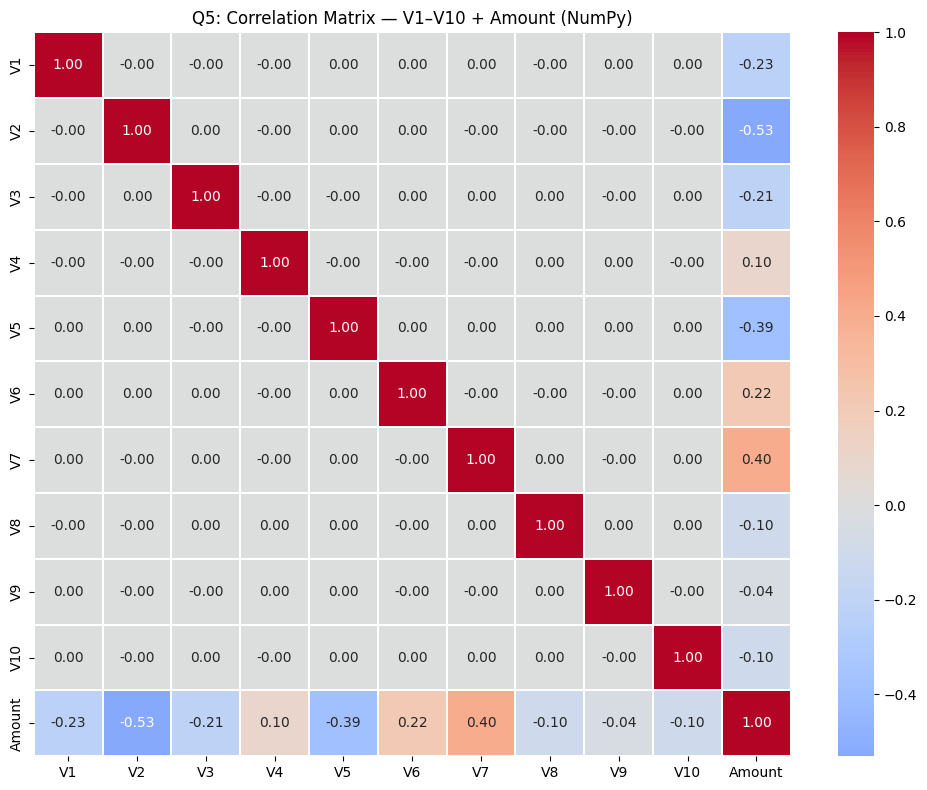

In [8]:
# x
# Q5. Correlation matrix V1–V10 + Amount
# 

v1_v10_idx = list(range(0, 10))               # V1–V10 ở cột 0–9
amt_idx    = [feature_cols.index('Amount')]   # Amount
X_q5       = X_np[:, v1_v10_idx + amt_idx]   # shape (284807, 11)

corr_matrix = np.corrcoef(X_q5.T)            # shape (11, 11)

labels = [f'V{i}' for i in range(1, 11)] + ['Amount']

print('=== Q5 — Correlation Matrix (V1–V10, Amount) ===')
print(f'{"":>8}', '  '.join(f'{l:>8}' for l in labels))
for i, row in enumerate(corr_matrix):
    print(f'{labels[i]:>8}', '  '.join(f'{v:>8.3f}' for v in row))

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, xticklabels=labels, yticklabels=labels,
            annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Q5: Correlation Matrix — V1–V10 + Amount (NumPy)')
plt.tight_layout()
plt.savefig('outputs/figures/q5_correlation_matrix.png', dpi=150)
plt.show()

In [9]:
# 
# Q6. Pairwise Euclidean Distance (100 giao dịch đầu)
#     Vectorized — không for-loop
# 

X100 = X_np[:100]                                    # (100, 29)

# Broadcasting trick: ||a - b||² = ||a||² + ||b||² - 2aᵀb
sq_norms = np.sum(X100**2, axis=1, keepdims=True)   # (100, 1)
dist_sq  = sq_norms + sq_norms.T - 2 * (X100 @ X100.T)
dist_sq  = np.maximum(dist_sq, 0)                    # tránh floating point âm nhỏ
dist_mat = np.sqrt(dist_sq)                          # (100, 100)

print('=== Q6 ===')
print(f'Distance matrix shape: {dist_mat.shape}')
print(f'Min non-zero dist: {dist_mat[dist_mat > 0].min():.4f}')
print(f'Max dist         : {dist_mat.max():.4f}')
print(f'Sample dist[0,1] : {dist_mat[0, 1]:.4f}')

=== Q6 ===
Distance matrix shape: (100, 100)
Min non-zero dist: 0.0000
Max dist         : 1402.2424
Sample dist[0,1] : 147.0225


=== Q7 ===
Original  — Mean: 88.35, Std: 250.12, Range: [0.00, 25691.16]
Min-Max   — Mean: 0.0034, Std: 0.0097, Range: [0.00, 1.00]
Z-score   — Mean: -0.0000, Std: 1.0000


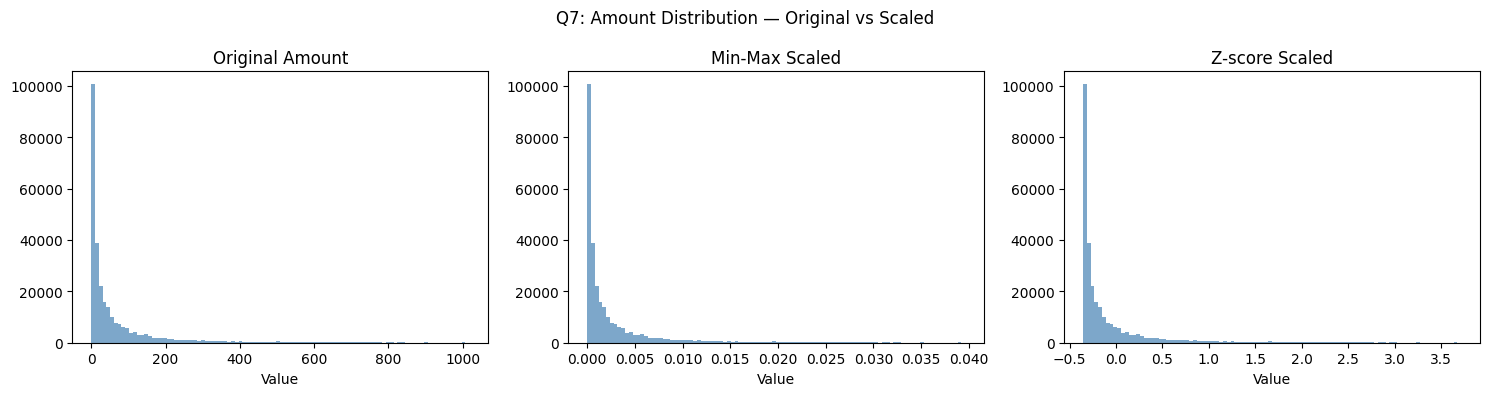

In [10]:
# Q7. Min-Max vs Z-score normalization cho Amount
#     Implement từ đầu, so sánh phân phối

amount = X_np[:, amount_idx]

# Min-Max
minmax_amount = (amount - amount.min()) / (amount.max() - amount.min())

# Z-score
zscore_amount = (amount - amount.mean()) / amount.std()

print('=== Q7 ===')
print(f'Original  — Mean: {amount.mean():.2f}, Std: {amount.std():.2f}, Range: [{amount.min():.2f}, {amount.max():.2f}]')
print(f'Min-Max   — Mean: {minmax_amount.mean():.4f}, Std: {minmax_amount.std():.4f}, Range: [{minmax_amount.min():.2f}, {minmax_amount.max():.2f}]')
print(f'Z-score   — Mean: {zscore_amount.mean():.4f}, Std: {zscore_amount.std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes,
    [amount, minmax_amount, zscore_amount],
    ['Original Amount', 'Min-Max Scaled', 'Z-score Scaled']):
    ax.hist(data[data < np.percentile(data, 99)], bins=100, color='steelblue', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Value')
plt.suptitle('Q7: Amount Distribution — Original vs Scaled')
plt.tight_layout()
plt.savefig('outputs/figures/q7_normalization_comparison.png', dpi=150)
plt.show()

In [ ]:
# Q8. Cosine Similarity giữa 2 fraud transactions (Class=1)

fraud_idx = np.where(y_np == 1)[0]     # index của các hàng fraud
np.random.seed(42)
i, j = np.random.choice(fraud_idx, size=2, replace=False)

a = X_np[i]
b = X_np[j]

cos_sim = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(f'Fraud transaction index : {i} và {j}')
print(f'Cosine similarity       : {cos_sim:.6f}')

=== Q8 ===
Fraud transaction index : 17407 và 12369
Cosine similarity       : 0.471336
Diễn giải: giá trị gần 1 = rất giống nhau, gần 0 = trực giao, gần -1 = đối lập


=== Q9 ===
Covariance matrix shape : (10, 10)
Top 5 eigenvalues       : [3.8365 2.7268 2.299  2.0047 1.9051]
Variance explained (%)  : PC1=19.3%, PC2=13.7%, PC3=11.6%
Projected data shape    : (284807, 3)


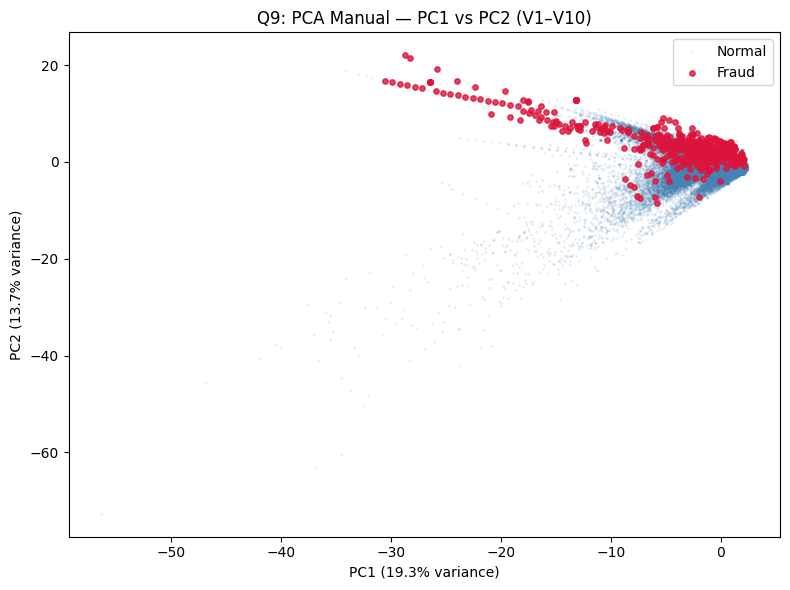

In [ ]:
# Q9. PCA thủ công trên V1–V10
#     Covariance matrix → Eigenvalues/vectors → Project top 3 PCs

X_q9 = X_np[:, :10].copy()            # V1–V10

# Bước 1: Chuẩn hóa (mean-centering)
X_centered = X_q9 - X_q9.mean(axis=0)

# Bước 2: Covariance matrix (10×10)
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

# Bước 3: Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)   # eigh cho symmetric matrix

# Bước 4: Sắp xếp giảm dần theo eigenvalue
sorted_idx  = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Bước 5: Project xuống 3 chiều
W3 = eigenvectors[:, :3]             # top 3 eigenvectors (10×3)
X_pca = X_centered @ W3              # (284807, 3)

# Variance explained
explained_var = eigenvalues / eigenvalues.sum() * 100

print(f'Covariance matrix shape : {cov_matrix.shape}')
print(f'Top 5 eigenvalues       : {eigenvalues[:5].round(4)}')
print(f'Variance explained (%)  : PC1={explained_var[0]:.1f}%, PC2={explained_var[1]:.1f}%, PC3={explained_var[2]:.1f}%')
print(f'Projected data shape    : {X_pca.shape}')

# Visualize PC1 vs PC2 — colored by Class
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y_np==0, 0], X_pca[y_np==0, 1], alpha=0.1, s=1, label='Normal', color='steelblue')
plt.scatter(X_pca[y_np==1, 0], X_pca[y_np==1, 1], alpha=0.8, s=15, label='Fraud', color='crimson')
plt.xlabel(f'PC1 ({explained_var[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]:.1f}% variance)')
plt.title('Q9: PCA Manual — PC1 vs PC2 (V1–V10)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/q9_pca_manual.png', dpi=150)
plt.show()

In [ ]:
# Q10. Batch Processing: chia 5000 giao dịch/batch, tính mean vector

batch_size  = 5000
n_batches   = len(X_np) // batch_size    # bỏ phần dư
X_batched   = X_np[:n_batches * batch_size].reshape(n_batches, batch_size, -1)

# Mean vector cho mỗi batch
batch_means = X_batched.mean(axis=1)     # shape (n_batches, 29)

print(f'Tổng giao dịch      : {len(X_np)}')
print(f'Số batches (5000)   : {n_batches}')
print(f'Batch means shape   : {batch_means.shape}')    # (56, 29)
print(f'Mean Amount batch 0 : {batch_means[0, amount_idx]:.4f}')
print(f'Mean Amount batch 1 : {batch_means[1, amount_idx]:.4f}')

=== Q10 ===
Tổng giao dịch      : 284807
Số batches (5000)   : 56
Batch means shape   : (56, 29)
Mean Amount batch 0 : 63.8011
Mean Amount batch 1 : 62.2593


---
## MODULE 2: MATHEMATICS FOR AI (Q1–Q10)

In [ ]:
# 
# Math Q1. Shape & Rank của matrix X (V1–V28)
# 

X_v128 = X_np[:, :28]    # chỉ V1–V28, không gồm Amount
rank   = np.linalg.matrix_rank(X_v128)

print(f'Shape của X    : {X_v128.shape}  (n_samples × n_features)')
print(f'Rank của X     : {rank}')
print(f'Full rank?     : {rank == min(X_v128.shape)}')

=== Math Q1 ===
Shape của X    : (284807, 28)  (n_samples × n_features)
Rank của X     : 28
Full rank?     : True


In [ ]:
# 
# Math Q2. Logistic Regression Hypothesis h(x)
#          Features: V1, V2, Amount → predict Class
# 

import sympy as sp

# Định nghĩa toán học
print()
print('Model: Binary Logistic Regression')
print('Input features: x = [V1, V2, Amount]')
print('Weights       : w = [w1, w2, w3]  +  bias b')
print()
print('Step 1 — Linear combination (z):')
print('  z = w1*V1 + w2*V2 + w3*Amount + b')
print()
print('Step 2 — Sigmoid activation:')
print('  h(x) = σ(z) = 1 / (1 + e^(-z))')
print()
print('Output: h(x) = P(Class=1 | x)  →  probability of fraud')
print('Decision: Class = 1 if h(x) >= 0.5, else 0')

# Demo với sklearn để thấy weights thực tế
features_q2 = ['V1', 'V2', 'Amount']
X_q2_lr = df[features_q2].values
y_q2    = df['Class'].values

# Scale Amount trước
X_q2_scaled = X_q2_lr.copy()
X_q2_scaled[:, 2] = (X_q2_lr[:, 2] - X_q2_lr[:, 2].mean()) / X_q2_lr[:, 2].std()

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_q2_scaled, y_q2)

print()
print('Weights học được từ data:')
for feat, w in zip(features_q2, lr.coef_[0]):
    print(f'  w_{feat:<8} = {w:>8.4f}')
print(f'  bias (b)  = {lr.intercept_[0]:>8.4f}')

=== Math Q2 — Hypothesis Function ===

Model: Binary Logistic Regression
Input features: x = [V1, V2, Amount]
Weights       : w = [w1, w2, w3]  +  bias b

Bước 1 — Linear combination (z):
  z = w1*V1 + w2*V2 + w3*Amount + b

Bước 2 — Sigmoid activation:
  h(x) = σ(z) = 1 / (1 + e^(-z))

Output: h(x) = P(Class=1 | x)  →  probability of fraud
Decision: Class = 1 if h(x) >= 0.5, else 0

Weights học được từ data:
  w_V1       =  -0.3113
  w_V2       =   0.7485
  w_Amount   =   0.7326
  bias (b)  =  -1.1335


In [ ]:
# 
# Math Q3. P(Class=1) và P(Class=1 | Amount > 500)
# 

n_total  = len(y_np)
n_fraud  = y_np.sum()

P_fraud  = n_fraud / n_total

# Conditional: Amount > 500
high_amt_mask     = X_np[:, amount_idx] > 500
n_high_amt        = high_amt_mask.sum()
n_fraud_high_amt  = (y_np[high_amt_mask]).sum()

P_fraud_given_high = n_fraud_high_amt / n_high_amt

print(f'P(Class=1)              = {n_fraud}/{n_total} = {P_fraud:.6f} ({P_fraud*100:.3f}%)')
print(f'P(Amount > 500)         = {n_high_amt}/{n_total} = {n_high_amt/n_total:.6f}')
print(f'P(Class=1 | Amount>500) = {n_fraud_high_amt}/{n_high_amt} = {P_fraud_given_high:.6f} ({P_fraud_given_high*100:.3f}%)')
#Insight: giao dịch lớn (>500) có tỉ lệ fraud {P_fraud_given_high/P_fraud:.1f}x so với baseline

=== Math Q3 ===
P(Class=1)              = 492/284807 = 0.001727 (0.173%)
P(Amount > 500)         = 9142/284807 = 0.032099
P(Class=1 | Amount>500) = 35/9142 = 0.003828 (0.383%)

Insight: giao dịch lớn (>500) có tỉ lệ fraud 2.2x so với baseline


In [ ]:
# Math Q4. Gradient của Binary Cross-Entropy Loss

print()
print('Loss function (Binary Cross-Entropy):')
print('      L(w) = -(1/m) * Σ [ y_i * log(h(x_i)) + (1 - y_i) * log(1 - h(x_i)) ]')
print()
#với h(x_i) = σ(w·x_i) = 1/(1 + e^(-w·x_i)
print('Đạo hàm theo w (gradient):')
print('      ∂L/∂w = (1/m) * Xᵀ * (h(X) - y)')
print()
# h(X) - y là vector lỗi dự đoán so với thực tế
# print('  Xᵀ nhân với error để "truyền ngược" gradient về từng weight
print()
#Key insight: gradient đơn giản và elegant vì sigmoid và log triệt tiêu nhau!
print()

# Minh họa bằng code
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))   # clip để tránh bị overflow

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def gradient(X, y, w, b):
    m   = len(y)
    z   = X @ w + b
    h   = sigmoid(z)
    err = h - y
    dw  = (X.T @ err) / m
    db  = err.mean()
    return dw, db



Loss function (Binary Cross-Entropy):
      L(w) = -(1/m) * Σ [ y_i * log(h(x_i)) + (1 - y_i) * log(1 - h(x_i)) ]

Đạo hàm theo w (gradient):
      ∂L/∂w = (1/m) * Xᵀ * (h(X) - y)





In [ ]:
v1 = X_np[:, 0]
v2 = X_np[:, 1]
amt = X_np[:, amount_idx]

var_amount = np.var(amt, ddof=1)               # sample variance
cov_v1_v2  = np.cov(v1, v2)[0, 1]             # off-diagonal

print(f'Variance của Amount  : {var_amount:.4f}')
print(f'Std dev của Amount   : {np.sqrt(var_amount):.4f}')
print(f'Covariance(V1, V2)   : {cov_v1_v2:.6f}')
print()
#Insight:Amount variance cao 62560 → phân phối rất rộng, cần scale trước khi train model
#Cov(V1, V2) ≈ {cov_v1_v2:.4f} → V1 và V2 gần như không tương quan'
#hợp lý vì V1–V28 là output của PCA → orthogonal với nhau




Variance của Amount  : 62560.0690
Std dev của Amount   : 250.1201
Covariance(V1, V2)   : -0.000000



In [44]:
# Math Q6. Covariance matrix V1–V10 + Eigenvalues & Eigenvectors
X_v10 = X_np[:, :10]                   # V1–V10
cov_v10 = np.cov(X_v10.T)             # shape (10, 10)

eigenvalues_q6, eigenvectors_q6 = np.linalg.eigh(cov_v10)
# Sắp xếp giảm dần
idx_sorted = np.argsort(eigenvalues_q6)[::-1]
eigenvalues_q6  = eigenvalues_q6[idx_sorted]
eigenvectors_q6 = eigenvectors_q6[:, idx_sorted]

print(f'Covariance matrix shape: {cov_v10.shape}')
print(f'Symmetric: {np.allclose(cov_v10, cov_v10.T)}')
print()
print('Eigenvalues (giảm dần):')
for i, ev in enumerate(eigenvalues_q6):
    pct = ev / eigenvalues_q6.sum() * 100
    print(f'  λ{i+1} = {ev:8.4f}  ({pct:.1f}% variance explained)')
print()
print(f'Eigenvectors shape: {eigenvectors_q6.shape}  (columns = principal directions)')

Covariance matrix shape: (10, 10)
Symmetric: True

Eigenvalues (giảm dần):
  λ1 =   3.8365  (19.3% variance explained)
  λ2 =   2.7268  (13.7% variance explained)
  λ3 =   2.2990  (11.6% variance explained)
  λ4 =   2.0047  (10.1% variance explained)
  λ5 =   1.9051  (9.6% variance explained)
  λ6 =   1.7749  (8.9% variance explained)
  λ7 =   1.5304  (7.7% variance explained)
  λ8 =   1.4265  (7.2% variance explained)
  λ9 =   1.2070  (6.1% variance explained)
  λ10 =   1.1856  (6.0% variance explained)

Eigenvectors shape: (10, 10)  (columns = principal directions)


=== Math Q7 — SVD ===
X shape  : (10000, 28)  →  X = U Σ Vᵀ
U shape  : (10000, 28)  ← left singular vectors (sample coordinates)
Σ shape  : (28,)  ← singular values (importance of each dim)
Vᵀ shape : (28, 28) ← right singular vectors (feature loadings)

Giải thích ý nghĩa:
  U   : mỗi cột là một "mode" — hướng biến thiên trong không gian mẫu
  Σ   : singular value lớn = chiều quan trọng, nhỏ = noise
  Vᵀ  : mỗi hàng là 1 principal component trong không gian feature

Cần 22 components để giải thích 95% variance (trong 28 features)


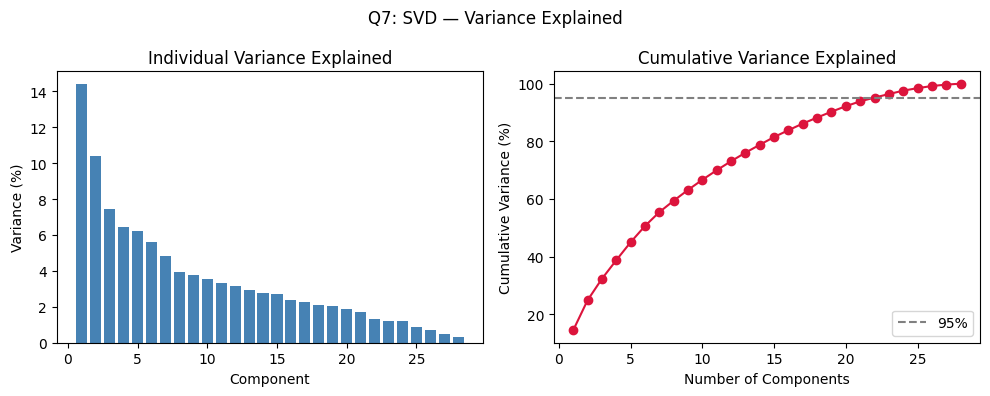

In [ ]:
# Math Q7. SVD trên X (V1–V28)
#          Giải thích U, Σ, Vᵀ trong dimensionality reduction

# SVD tốn RAM với 284K rows → dùng sample 10K
np.random.seed(42)
sample_idx = np.random.choice(len(X_v128), size=10000, replace=False)
X_svd = X_v128[sample_idx]             # (10000, 28)
X_svd_centered = X_svd - X_svd.mean(axis=0)

U, S, Vt = np.linalg.svd(X_svd_centered, full_matrices=False)

print(f'X shape  : {X_svd_centered.shape}  →  X = U Σ Vᵀ')
print(f'U shape  : {U.shape}  ← left singular vectors (sample coordinates)')
print(f'Σ shape  : {S.shape}  ← singular values (importance of each dim)')
print(f'Vᵀ shape : {Vt.shape} ← right singular vectors (feature loadings)')
print()
print('Giải thích ý nghĩa:')
print('  U   : mỗi cột là một "mode" — hướng biến thiên trong không gian mẫu')
print('  Σ   : singular value lớn = chiều quan trọng, nhỏ = noise')
print('  Vᵀ  : mỗi hàng là 1 principal component trong không gian feature')
print()

# Variance explained bởi k components
var_explained = (S**2) / (S**2).sum()
cum_var = np.cumsum(var_explained)
k95 = np.searchsorted(cum_var, 0.95) + 1
print(f'Cần {k95} components để giải thích 95% variance (trong 28 features)')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, 29), var_explained * 100, color='steelblue')
plt.xlabel('Component'); plt.ylabel('Variance (%)')
plt.title('Individual Variance Explained')
plt.subplot(1, 2, 2)
plt.plot(range(1, 29), cum_var * 100, 'o-', color='crimson')
plt.axhline(95, color='gray', linestyle='--', label='95%')
plt.xlabel('Number of Components'); plt.ylabel('Cumulative Variance (%)')
plt.title('Cumulative Variance Explained'); plt.legend()
plt.suptitle('Q7: SVD — Variance Explained')
plt.tight_layout()
plt.savefig('outputs/figures/q7_svd_variance.png', dpi=150)
plt.show()

Iter  100 | Loss: 0.112129
Iter  200 | Loss: 0.059302
Iter  300 | Loss: 0.041573
Iter  400 | Loss: 0.032851
Iter  500 | Loss: 0.027704

Final weights: w = [-0.0644  0.0763  0.0254],  b = -3.8197


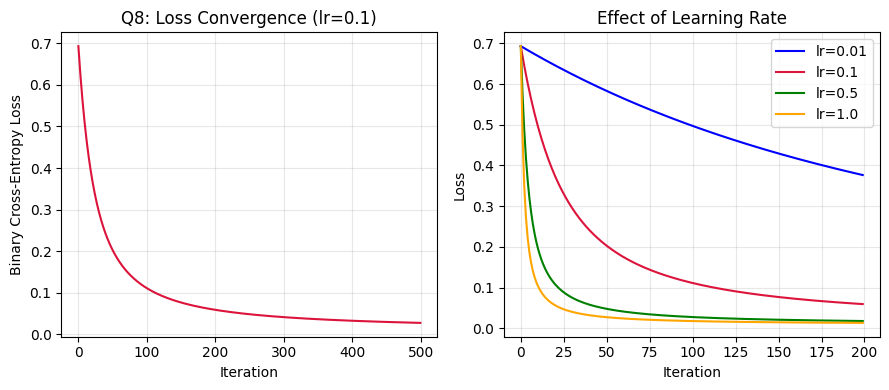

In [ ]:
# Math Q8. Gradient Descent tối ưu Logistic Regression
#  Visualize loss convergence

# Chuẩn bị data: V1, V2, Amount (scaled)
X_gd = df[['V1', 'V2', 'Amount']].values.copy()
X_gd[:, 2] = zscore_amount   # dùng Z-score Amount đã tính
y_gd = y_np.astype(np.float64)

# Khởi tạo weights
np.random.seed(42)
w = np.zeros(X_gd.shape[1])
b = 0.0
lr_rate = 0.1
n_iters = 500

loss_history = []

for i in range(n_iters):
    # Forward
    h = sigmoid(X_gd @ w + b)
    loss = binary_cross_entropy(y_gd, h)
    loss_history.append(loss)
    # Backward
    dw, db = gradient(X_gd, y_gd, w, b)
    # Update
    w -= lr_rate * dw
    b -= lr_rate * db
    if (i+1) % 100 == 0:
        print(f'Iter {i+1:4d} | Loss: {loss:.6f}')

print(f'\nFinal weights: w = {w.round(4)},  b = {b:.4f}')

# Visualize loss curve
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='crimson', linewidth=1.5)
plt.xlabel('Iteration'); plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Q8: Loss Convergence (lr=0.1)')
plt.grid(alpha=0.3)

# Thử nhiều learning rates
plt.subplot(1, 2, 2)
for lr_r, color in [(0.01, 'blue'), (0.1, 'crimson'), (0.5, 'green'), (1.0, 'orange')]:
    w_t = np.zeros(X_gd.shape[1]); b_t = 0.0
    losses = []
    for _ in range(200):
        h_t = sigmoid(X_gd @ w_t + b_t)
        losses.append(binary_cross_entropy(y_gd, h_t))
        dw_t, db_t = gradient(X_gd, y_gd, w_t, b_t)
        w_t -= lr_r * dw_t; b_t -= lr_r * db_t
    plt.plot(losses, label=f'lr={lr_r}', color=color)
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('Effect of Learning Rate'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/q8_gradient_descent.png', dpi=150)
plt.show()

In [ ]:
# Math Q9. Bayes' Theorem: P(Fraud | High Amount)
#          Discretize Amount - Low / Medium / High

amount_series = df['Amount']
df_q9 = df[['Amount', 'Class']].copy()

# Discretize Amount thành 3 bins
bins   = [0, 100, 500, amount_series.max() + 1]
labels_q9 = ['Low', 'Medium', 'High']
df_q9['AmountBin'] = pd.cut(df_q9['Amount'], bins=bins, labels=labels_q9)

n_total   = len(df_q9)
P_F       = df_q9['Class'].mean()                    # P(Fraud)

for bin_name in labels_q9:
    mask_bin    = df_q9['AmountBin'] == bin_name
    P_bin       = mask_bin.mean()                    # P(Bin)
    P_bin_F     = df_q9.loc[mask_bin & (df_q9['Class']==1)].shape[0] / df_q9['Class'].sum()  # P(Bin|Fraud)
    
    # Bayes: P(Fraud|Bin) = P(Bin|Fraud) * P(Fraud) / P(Bin)
    P_F_given_bin = (P_bin_F * P_F) / P_bin
    
    print(f'=== {bin_name} Amount ===')
    print(f'  P({bin_name})              = {P_bin:.4f}')
    print(f'  P({bin_name} | Fraud)      = {P_bin_F:.4f}')
    print(f'  P(Fraud | {bin_name}) Bayes = {P_F_given_bin:.6f} ({P_F_given_bin*100:.4f}%)')
    print()

=== Low Amount ===
  P(Low)              = 0.7952
  P(Low | Fraud)      = 0.6809
  P(Fraud | Low) Bayes = 0.001479 (0.1479%)

=== Medium Amount ===
  P(Medium)              = 0.1663
  P(Medium | Fraud)      = 0.1931
  P(Fraud | Medium) Bayes = 0.002006 (0.2006%)

=== High Amount ===
  P(High)              = 0.0321
  P(High | Fraud)      = 0.0711
  P(Fraud | High) Bayes = 0.003828 (0.3828%)



L1 C=0.01 | Non-zero: 15/15 | Max|w|=0.7442
L1 C=0.1  | Non-zero: 15/15 | Max|w|=0.7562
L1 C=1.0  | Non-zero: 15/15 | Max|w|=0.7574
L2 C=0.01 | Non-zero: 15/15 | Max|w|=0.7533
L2 C=0.1  | Non-zero: 15/15 | Max|w|=0.7574
L2 C=1.0  | Non-zero: 15/15 | Max|w|=0.7580



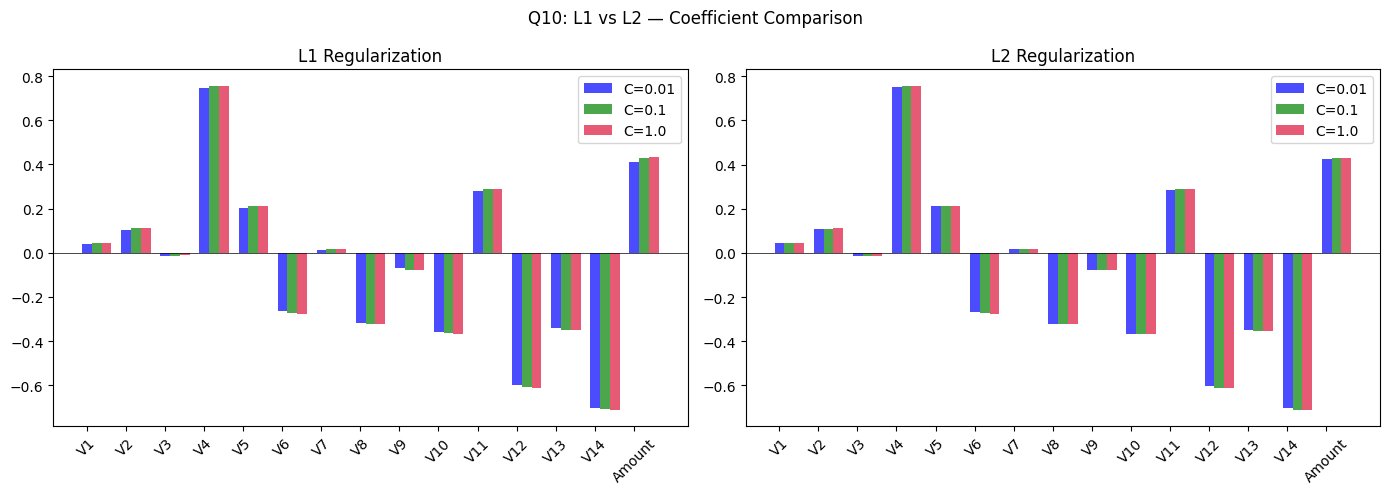

In [45]:
# Math Q10. L1 (Lasso) vs L2 (Ridge) Regularization
#           So sánh sparsity của coefficients

from sklearn.linear_model import LogisticRegression

features_q10 = [f'V{i}' for i in range(1, 15)] + ['Amount']
X_q10 = df[features_q10].values.copy()
# Scale Amount
X_q10[:, -1] = (X_q10[:, -1] - X_q10[:, -1].mean()) / X_q10[:, -1].std()
y_q10 = df['Class'].values

results = {}
for C, penalty, solver in [
    (0.01, 'l1', 'liblinear'),
    (0.1,  'l1', 'liblinear'),
    (1.0,  'l1', 'liblinear'),
    (0.01, 'l2', 'lbfgs'),
    (0.1,  'l2', 'lbfgs'),
    (1.0,  'l2', 'lbfgs'),
]:
    model = LogisticRegression(C=C, penalty=penalty, solver=solver,
                                class_weight='balanced', max_iter=1000)
    model.fit(X_q10, y_q10)
    coef = model.coef_[0]
    n_zero = np.sum(np.abs(coef) < 1e-6)
    results[f'{penalty.upper()} C={C}'] = coef
    print(f'{penalty.upper()} C={C:<4} | Non-zero: {len(coef)-n_zero:>2}/{len(coef)} | Max|w|={np.abs(coef).max():.4f}')

#L1 (Lasso) → nhiều coefficient = 0 (sparse model) → automatic feature selection
#L2 (Ridge) → tất cả coefficient nhỏ nhưng khác 0 → smooth shrinkage


# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, penalty, solver in [(axes[0], 'l1', 'liblinear'), (axes[1], 'l2', 'lbfgs')]:
    for C, color in [(0.01, 'blue'), (0.1, 'green'), (1.0, 'crimson')]:
        m = LogisticRegression(C=C, penalty=penalty, solver=solver,
                               class_weight='balanced', max_iter=1000)
        m.fit(X_q10, y_q10)
        ax.bar(np.arange(len(features_q10)) + (0.01 + 0.25*[0.01,0.1,1.0].index(C)),
               m.coef_[0], width=0.25, alpha=0.7, label=f'C={C}', color=color)
    ax.set_xticks(range(len(features_q10)))
    ax.set_xticklabels(features_q10, rotation=45)
    ax.set_title(f'{penalty.upper()} Regularization')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend()
plt.suptitle('Q10: L1 vs L2 — Coefficient Comparison')
plt.tight_layout()
plt.savefig('outputs/figures/q10_regularization.png', dpi=150)
plt.show()

---
## MODULE 3: PANDAS (Q1–Q10)

In [47]:
# Pandas Q1. Load DataFrame, head / info / describe
display(df.head())

print('\n--- info() ---')
df.info()

print('\n--- describe() cho Amount và Class ---')
display(df[['Time', 'Amount', 'Class']].describe().round(4))

print('\nPotential anomalies to note:')
print(f'  - Amount: min={df.Amount.min():.2f}, max={df.Amount.max():.2f} → cần scale')
print(f'  - Class : {df.Class.value_counts().to_dict()} → HIGHLY IMBALANCED')
print(f'  - Time  : từ 0 đến {df.Time.max():.0f}s (~2 ngày)')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21  

,Time,Amount,Class
count,284807.0000,284807.0000,284807.0000
mean,94813.8596,88.3496,0.0017
std,47488.1460,250.1201,0.0415
min,0.0000,0.0000,0.0000
25%,54201.5000,5.6000,0.0000
50%,84692.0000,22.0000,0.0000
75%,139320.5000,77.1650,0.0000
max,172792.0000,25691.1600,1.0000



Potential anomalies to note:
  - Amount: min=0.00, max=25691.16 → cần scale
  - Class : {0: 284315, 1: 492} → HIGHLY IMBALANCED
  - Time  : từ 0 đến 172792s (~2 ngày)


In [ ]:
# Pandas Q2. Missing values, duplicates, class imbalance ratio

print(f'Missing values: {df.isnull().sum().sum()} (tổng toàn dataset)')
print(f'Duplicate rows: {df.duplicated().sum()}')

n_fraud_p  = df['Class'].sum()
n_legit_p  = len(df) - n_fraud_p
ratio      = n_legit_p / n_fraud_p

print(f'\nClass Distribution:')
print(f'  Normal (0) : {n_legit_p:>7,} ({n_legit_p/len(df)*100:.3f}%)')
print(f'  Fraud  (1) : {n_fraud_p:>7,} ({n_fraud_p/len(df)*100:.3f}%)')
print(f'  Imbalance ratio: {ratio:.1f}:1 (normal:fraud)')

#dùng class_weight="balanced" hoặc SMOTE khi train model

=== Pandas Q2 ===
Missing values: 0 (tổng toàn dataset)
Duplicate rows: 1081

Class Distribution:
  Normal (0) : 284,315 (99.827%)
  Fraud  (1) :     492 (0.173%)
  Imbalance ratio: 577.9:1 (normal:fraud)

Implication: dùng class_weight="balanced" hoặc SMOTE khi train model


In [49]:
# Pandas Q3. GroupBy Class → avg Amount & Time
print('=== Pandas Q3 ===')
grouped = df.groupby('Class')[['Amount', 'Time']].agg(['mean', 'median', 'std'])
display(grouped.round(4))

print()
avg_fraud   = df[df.Class==1]['Amount'].mean()
avg_normal  = df[df.Class==0]['Amount'].mean()
print(f'Average Amount — Fraud:  ${avg_fraud:.2f}')
print(f'Average Amount — Normal: ${avg_normal:.2f}')
print(f"\nfraud transactions có avg amount {'higher' if avg_fraud > avg_normal else 'lower'} ({avg_fraud/avg_normal:.2f}x) so với normal")

=== Pandas Q3 ===


Amount                         Time                     
           mean median       std        mean   median         std
Class                                                            
0       88.2910  22.00  250.1051  94838.2023  84711.0  47484.0158
1      122.2113   9.25  256.6833  80746.8069  75568.5  47835.3651


Average Amount — Fraud:  $122.21
Average Amount — Normal: $88.29

fraud transactions có avg amount higher (1.38x) so với normal


In [50]:
# Pandas Q4. Feature 'TransactionFrequency' từ Time difference

df_q4 = df.copy()
df_q4['TransactionFrequency'] = df_q4['Time'].diff().fillna(0)

print(df_q4[['Time', 'TransactionFrequency', 'Class']].head(10).to_string())
print(f'\nStatistics:')
print(df_q4.groupby('Class')['TransactionFrequency'].describe().round(2))

   Time  TransactionFrequency  Class
0   0.0                   0.0      0
1   0.0                   0.0      0
2   1.0                   1.0      0
3   1.0                   0.0      0
4   2.0                   1.0      0
5   2.0                   0.0      0
6   4.0                   2.0      0
7   7.0                   3.0      0
8   7.0                   0.0      0
9   9.0                   2.0      0

Statistics:
          count  mean   std  min  25%  50%  75%   max
Class                                                
0      284315.0  0.61  1.05  0.0  0.0  0.0  1.0  32.0
1         492.0  1.09  1.87  0.0  0.0  0.0  1.0  16.0


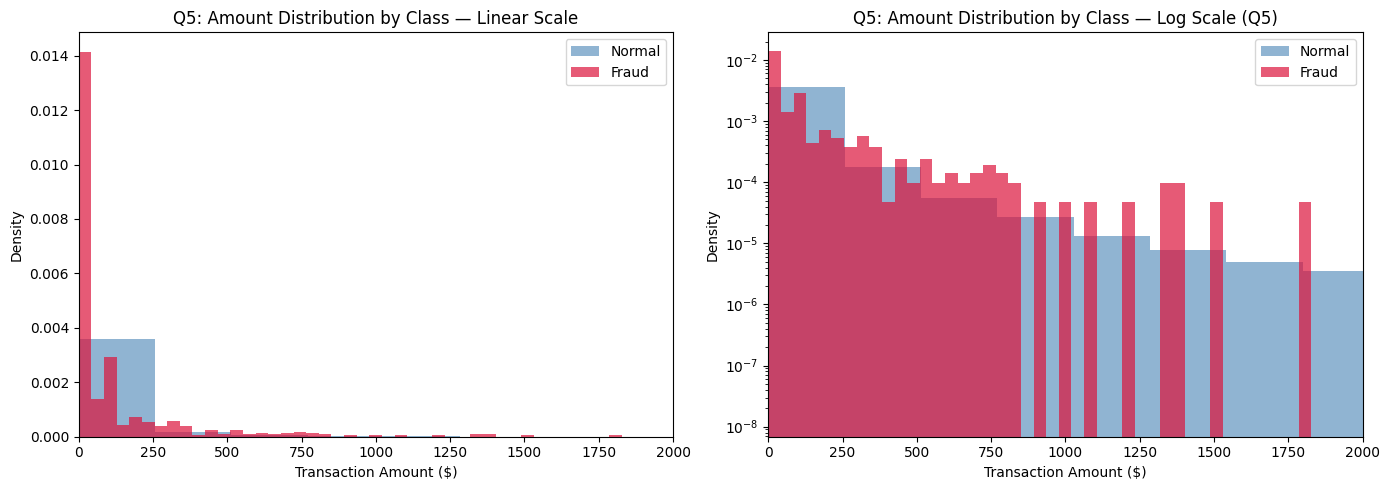

Insight: Log scale cho thấy fraud transactions tập trung ở amount thấp-vừa,
         rất ít fraud ở high amount — counter-intuitive!


In [ ]:
# Pandas Q5. Histogram Amount theo Class (log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, yscale, title in [
    (axes[0], 'linear', 'Linear Scale'),
    (axes[1], 'log',    'Log Scale (Q5)'),
]:
    ax.hist(df[df.Class==0]['Amount'], bins=100, alpha=0.6, label='Normal', color='steelblue', density=True)
    ax.hist(df[df.Class==1]['Amount'], bins=50,  alpha=0.7, label='Fraud',  color='crimson',   density=True)
    ax.set_yscale(yscale)
    ax.set_xlabel('Transaction Amount ($)')
    ax.set_ylabel('Density')
    ax.set_title(f'Q5: Amount Distribution by Class — {title}')
    ax.legend()
    ax.set_xlim(0, 2000)

plt.tight_layout()
plt.savefig('outputs/figures/q5_amount_histogram.png', dpi=150)
plt.show()

print('         Log scale cho thấy fraud transactions tập trung ở amount thấp-vừa,')
print('         rất ít fraud ở high amount — counter-intuitive!')

In [ ]:
# Pandas Q6. Pivot table: Amount bins × Class

df_q6 = df.copy()
df_q6['AmountBin'] = pd.cut(df_q6['Amount'],
    bins=[0, 10, 50, 100, 500, 1000, df['Amount'].max()+1],
    labels=['0–10', '10–50', '50–100', '100–500', '500–1000', '>1000'])

pivot = pd.pivot_table(df_q6, values='Time', index='AmountBin',
                       columns='Class', aggfunc='count', fill_value=0)
pivot.columns = ['Normal', 'Fraud']
pivot['Fraud Rate (%)'] = (pivot['Fraud'] / (pivot['Normal'] + pivot['Fraud']) * 100).round(4)
pivot['Total'] = pivot['Normal'] + pivot['Fraud']

display(pivot)
print()
print(f"\nfraud rate cao nhất ở Amount range {pivot['Fraud Rate (%)'].idxmax()} với {pivot['Fraud Rate (%)'].max()}%")

,Normal,Fraud,Fraud Rate (%),Total
AmountBin,,,,
0–10,98217,222,0.2255,98439
10–50,90724,57,0.0628,90781
50–100,37198,56,0.1503,37254
100–500,47271,95,0.2006,47366
500–1000,6176,26,0.4192,6202
>1000,2931,9,0.3061,2940




Insight: fraud rate cao nhất ở Amount range 500–1000 với 0.4192%


,Total,Fraud,FraudRate
TimeSlot,,,
Night (0–6h),23934,124,0.5181
Morning (6–12h),70912,118,0.1664
Afternoon (12–18h),96435,134,0.1390
Evening (18–24h),93526,116,0.1240


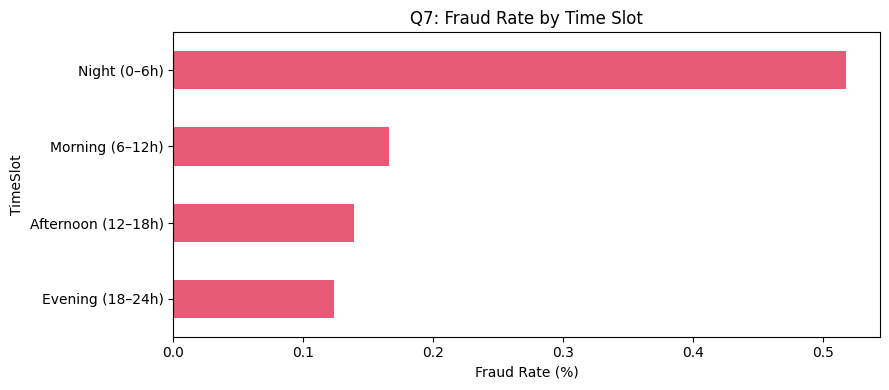

In [57]:
# Pandas Q7. Time-based fraud rate: morning / afternoon / night
df_q7 = df.copy()
time_of_day = df_q7['Time'] % 86400       # seconds trong ngày

def time_slot(s):
    if s < 21600:   return 'Night (0–6h)'
    elif s < 43200: return 'Morning (6–12h)'
    elif s < 64800: return 'Afternoon (12–18h)'
    else:           return 'Evening (18–24h)'

df_q7['TimeSlot'] = time_of_day.apply(time_slot)

slot_analysis = df_q7.groupby('TimeSlot')['Class'].agg(
    Total='count',
    Fraud='sum'
).assign(FraudRate=lambda x: (x['Fraud']/x['Total']*100).round(4))

display(slot_analysis.sort_values('FraudRate', ascending=False))

# Visualize
plt.figure(figsize=(9, 4))
slot_analysis.sort_values('FraudRate', ascending=True)['FraudRate'].plot(
    kind='barh', color='crimson', alpha=0.7)
plt.xlabel('Fraud Rate (%)')
plt.title('Q7: Fraud Rate by Time Slot')
plt.tight_layout()
plt.savefig('outputs/figures/q7_timeslot_fraud_rate.png', dpi=150)
plt.show()

In [ ]:
# Pandas Q8. TransactionSize (Small/Medium/Large) theo quartile
#            Phân tích fraud behavior theo size

df_q8 = df.copy()
# Quartile-based: Q1, Q2, Q3 là cut points
df_q8['TransactionSize'] = pd.qcut(
    df_q8['Amount'],
    q=3,
    labels=['Small', 'Medium', 'Large'],
    duplicates='drop'
)

size_analysis = df_q8.groupby('TransactionSize')['Class'].agg(
    Total='count', Fraud='sum'
).assign(
    FraudRate=lambda x: (x['Fraud']/x['Total']*100).round(4),
    AmountRange=df_q8.groupby('TransactionSize')['Amount'].agg(lambda x: f"${x.min():.2f}–${x.max():.2f}")
)

display(size_analysis)

=== Pandas Q8 — Fraud Behavior by Transaction Size ===


,Total,Fraud,FraudRate,AmountRange
TransactionSize,,,,
Small,97314,249,0.2559,$0.00–$9.99
Medium,93731,57,0.0608,$10.00–$50.00
Large,93762,186,0.1984,$50.01–$25691.16


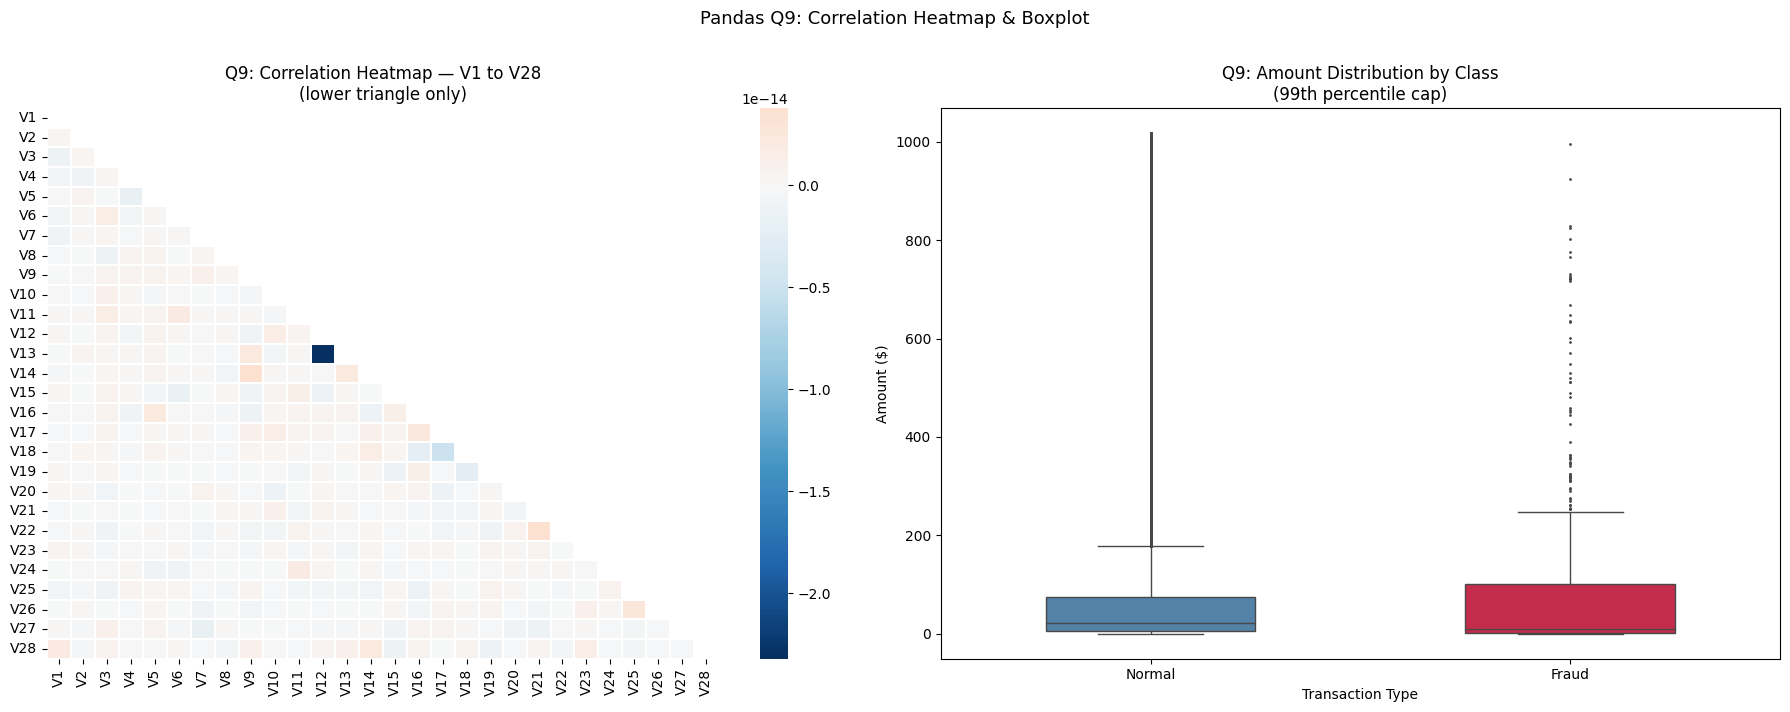

In [ ]:
#Pandas Q9. Correlation Heatmap V1–V28 + Boxplot Amount by Class
#            Visualization đẹp nhất trong project!

v_cols = [f'V{i}' for i in range(1, 29)]
corr_v = df[v_cols].corr()

#Heatmap với mask triangle trên để trông clean hơn
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.triu(np.ones_like(corr_v, dtype=bool))
sns.heatmap(corr_v, ax=axes[0],
            mask=mask,
            cmap='RdBu_r', center=0,
            annot=False, linewidths=0.2,
            xticklabels=True, yticklabels=True)
axes[0].set_title('Q9: Correlation Heatmap — V1 to V28\n(lower triangle only)')

# Boxplot Amount by Class
df_box = df.copy()
df_box['Class_Label'] = df_box['Class'].map({0: 'Normal', 1: 'Fraud'})
df_box_filtered = df_box[df_box['Amount'] < df_box['Amount'].quantile(0.99)]  #loại outlier

sns.boxplot(data=df_box_filtered, x='Class_Label', y='Amount',
            palette={'Normal': 'steelblue', 'Fraud': 'crimson'},
            ax=axes[1], width=0.5, showfliers=True, fliersize=1)
axes[1].set_title('Q9: Amount Distribution by Class\n(99th percentile cap)')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Amount ($)')

plt.suptitle('Pandas Q9: Correlation Heatmap & Boxplot', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/q9_heatmap_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
# Pandas Q10. RobustScaler cho Amount & Time → Final Dataset
#             (V1–V28 đã scale sẵn từ PCA)

df_final = df.copy()

scaler = RobustScaler()    # robust với outliers (dùng median & IQR thay vì mean & std)
df_final[['Amount_scaled', 'Time_scaled']] = scaler.fit_transform(df_final[['Amount', 'Time']])

#Drop cột gốc, giữ scaled
df_final = df_final.drop(columns=['Amount', 'Time'])

print(f'Shape: {df_final.shape}')
print(f'Columns: {list(df_final.columns)}')
print()
print(df_final[['Amount_scaled', 'Time_scaled', 'Class']].describe().round(4))

# Lưu file
df_final.to_csv(r'D:/WORKSPACE/QuanSkill/data/processed/creditcard_processed.csv', index=False)
print(f'\nSaved to data/processed/creditcard_processed.csv')

Shape: (284807, 31)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']

       Amount_scaled  Time_scaled        Class
count    284807.0000  284807.0000  284807.0000
mean          0.9271       0.1189       0.0017
std           3.4950       0.5579       0.0415
min          -0.3074      -0.9950       0.0000
25%          -0.2292      -0.3582       0.0000
50%           0.0000       0.0000       0.0000
75%           0.7708       0.6418       0.0000
max         358.6832       1.0350       1.0000

Saved to data/processed/creditcard_processed.csv
